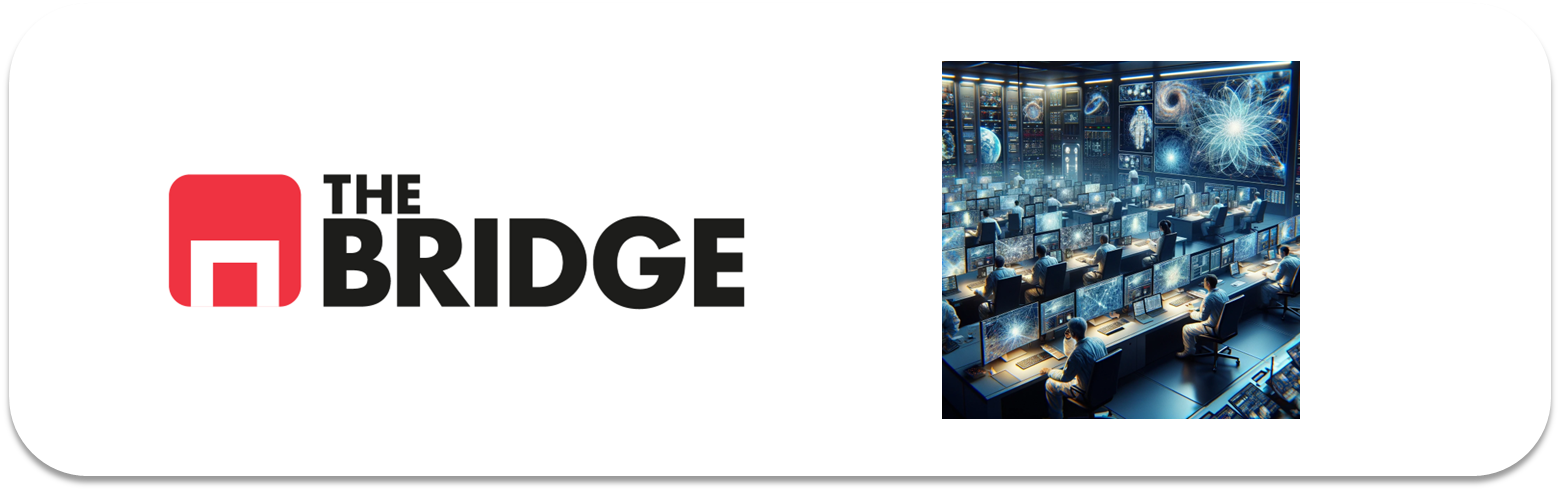

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [6]:
# EJERCICIO 0 - IMPORTACIONES

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [7]:
!pip install kagglehub

In [8]:
# EJERCICIO 1 - DESCARGA DEL DATASET

import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Ruta del dataset:", path)

Ruta del dataset: /Users/ivan/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [9]:
# EJERCICIO 1 - RUTAS Y PARÁMETROS

DATASET_DIR = Path(path)

TRAIN_DIR = DATASET_DIR / "seg_train"
TEST_DIR = DATASET_DIR / "seg_test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("¿Existe TRAIN_DIR?", TRAIN_DIR.exists())
print("¿Existe TEST_DIR?", TEST_DIR.exists())

TRAIN_DIR: /Users/ivan/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train
TEST_DIR: /Users/ivan/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test
¿Existe TRAIN_DIR? True
¿Existe TEST_DIR? True


In [10]:
# EJERCICIO 1 - CARGA DE DATOS

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Clases:", class_names)
print("Número de clases:", num_classes)

Found 14034 files belonging to 1 classes.
Found 3000 files belonging to 1 classes.
Clases: ['seg_train']
Número de clases: 1


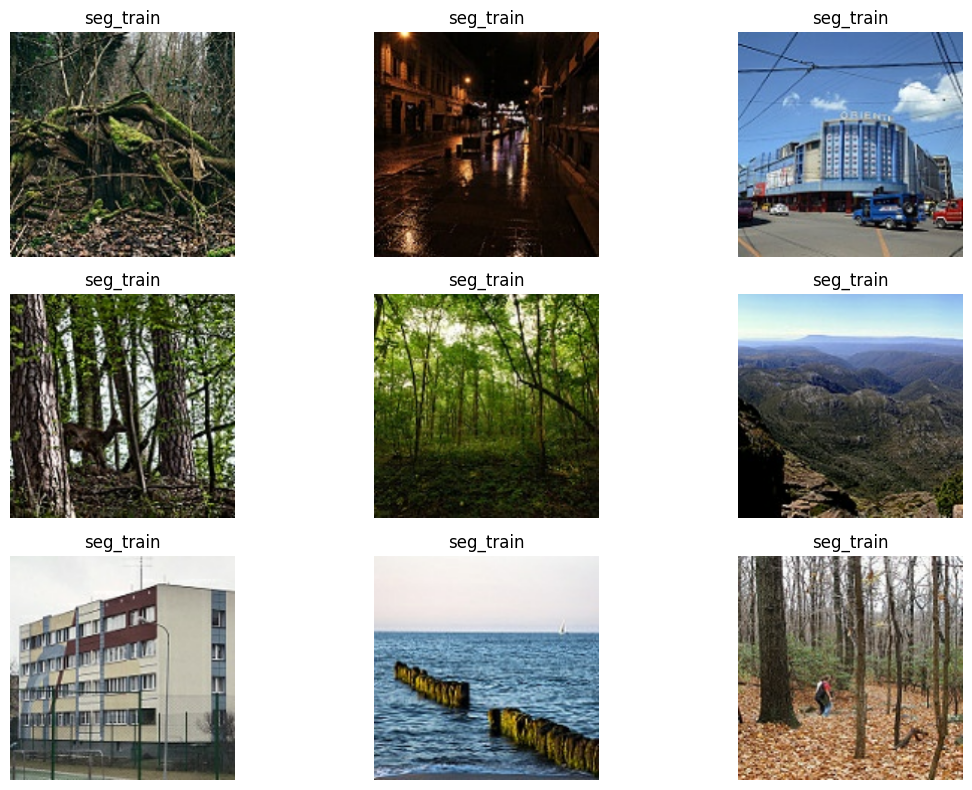

In [11]:
# EJERCICIO 1 - VISUALIZACIÓN DE IMÁGENES

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# EJERCICIO 1 - PREPROCESADO

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [13]:
# EJERCICIO 1 - FUNCIÓN PARA GRAFICAR EL HISTÓRICO

def plot_history(history, title="Entrenamiento"):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [14]:
# EJERCICIO 1 - FUNCIÓN DE EVALUACIÓN

def evaluate_model(model, dataset, class_names):
    y_true = np.concatenate([y for x, y in dataset], axis=0)
    y_pred_probs = model.predict(dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Matriz de confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
# EJERCICIO 2 - ELECCIÓN DEL MODELO

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Modelo base cargado correctamente.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Modelo base cargado correctamente.


In [16]:
# EJERCICIO 3 - TRANSFER LEARNING

inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

# Cabeza con una capa densa oculta
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
EPOCHS_TRANSFER = 2

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_TRANSFER
)

Epoch 1/2


439/439 ━━━━━━━━━━━━━━━━━━━━ 103s 235ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/2
439/439 ━━━━━━━━━━━━━━━━━━━━ 103s 235ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


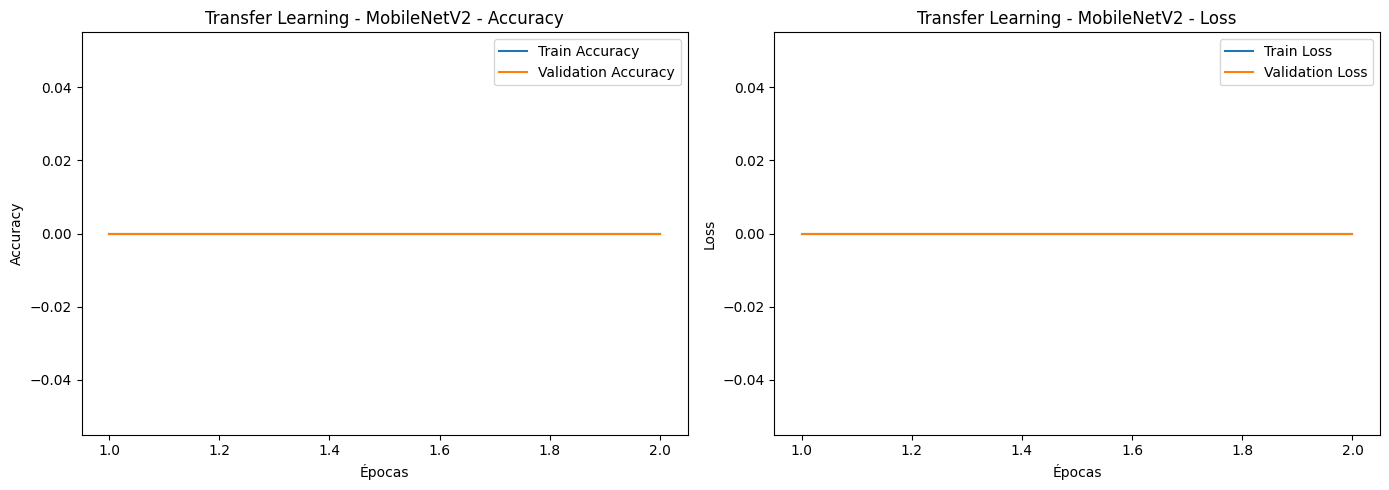

In [19]:
plot_history(history_transfer, title="Transfer Learning - MobileNetV2")

In [20]:
test_loss_tl, test_acc_tl = transfer_model.evaluate(test_ds)

print(f"Loss en test (Transfer Learning): {test_loss_tl:.4f}")
print(f"Accuracy en test (Transfer Learning): {test_acc_tl:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Loss en test (Transfer Learning): 0.0000
Accuracy en test (Transfer Learning): 0.0000


/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step
Classification Report:

              precision    recall  f1-score   support

   seg_train       1.00      1.00      1.00      3000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


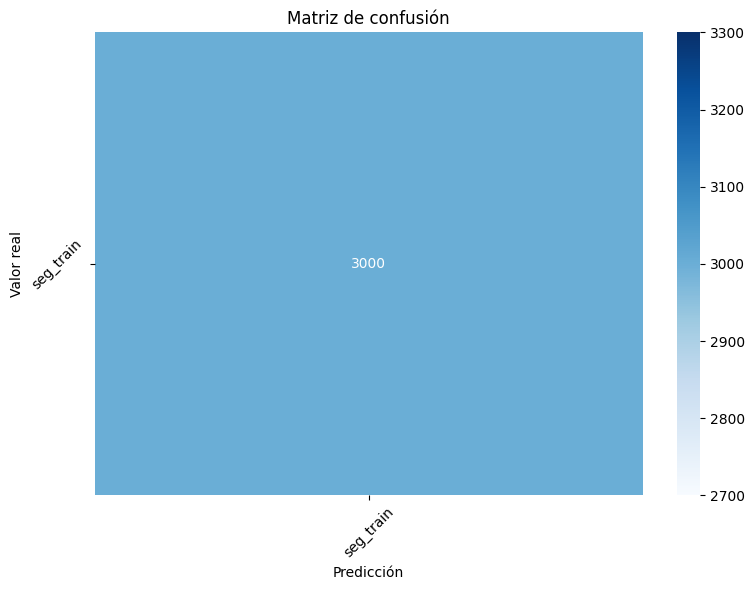

In [21]:
evaluate_model(transfer_model, test_ds, class_names)

In [22]:

# EJERCICIO 4 - FINE TUNING

base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [23]:
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
EPOCHS_FINE = 2
TOTAL_EPOCHS = EPOCHS_TRANSFER + EPOCHS_FINE

history_fine = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_transfer.epoch[-1] + 1
)

Epoch 3/4


/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 380ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/4
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 394ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00


In [25]:
test_loss_ft, test_acc_ft = transfer_model.evaluate(test_ds)

print(f"Loss en test (Fine Tuning): {test_loss_ft:.4f}")
print(f"Accuracy en test (Fine Tuning): {test_acc_ft:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Loss en test (Fine Tuning): 0.0000
Accuracy en test (Fine Tuning): 0.0000


/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step
Classification Report:

              precision    recall  f1-score   support

   seg_train       1.00      1.00      1.00      3000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



/Users/ivan/Desktop/DS-ONLINE-BOOTCAMP/DS-ONLINE-BETA/venv_xgb/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


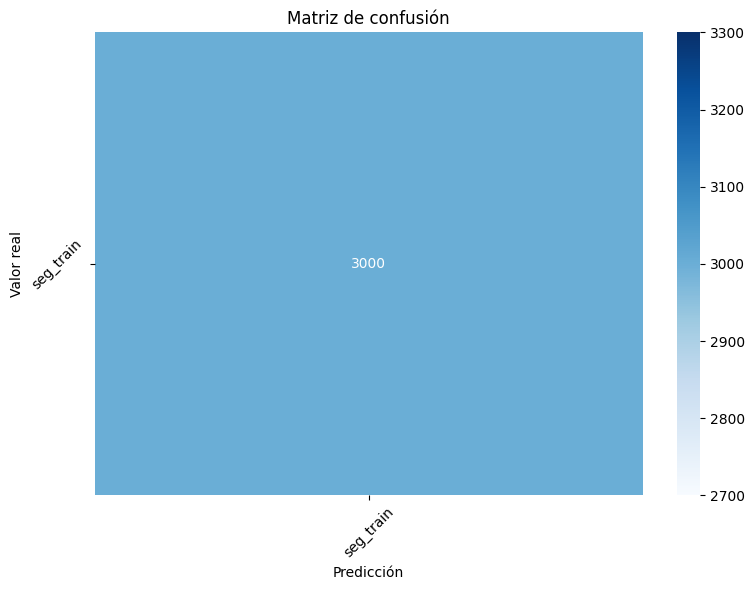

In [26]:
evaluate_model(transfer_model, test_ds, class_names)

In [27]:

# EJERCICIO 5 - COMPARACIÓN DE RESULTADOS

# Sustituye este valor por el accuracy que obtuviste en tu CNN anterior
acc_cnn_manual = 0.00

resultados = pd.DataFrame({
    "Modelo": [
        "CNN ad-hoc",
        "Transfer Learning (MobileNetV2)",
        "Fine Tuning (MobileNetV2)"
    ],
    "Accuracy test": [
        acc_cnn_manual,
        test_acc_tl,
        test_acc_ft
    ]
})

resultados

,Modelo,Accuracy test
0,CNN ad-hoc,0.0
1,Transfer Learning (MobileNetV2),0.0
2,Fine Tuning (MobileNetV2),0.0
